# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
base = pd.read_csv('marketing_campaign.csv', delimiter=';')
base

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,46,709,43,182,42,118,247,4,5,0,1
2236,1946,PhD,Together,64014.0,2,56,406,0,30,0,0,8,5,7,0,1
2237,1981,Graduation,Divorced,56981.0,0,91,908,48,217,32,12,24,13,6,0,0
2238,1956,Master,Together,69245.0,0,8,428,30,214,80,30,61,10,3,0,1


In [3]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

Analisando as colunas do dataframe, observa-se que há 2 colunas categóricas, enquanto as demais são numéricas. Além disso, apenas a coluna `Income` possui valores nulos.

In [4]:
base.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25173.076661,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


In [5]:
# Preenchendo os valores faltantes da coluna Income com a média
base['Income'] = base['Income'].fillna(base['Income'].mean())

## Agora iremos analisar cada coluna individualmente para verificar a presença de outliers.

### Coluna `Year_Birth`

Esta coluna parece estar relativamente balanceada, apresentando uma média muito próxima da mediana. No entanto, nota-se a possível presença de outliers inferiores.

In [6]:
base['Year_Birth'].value_counts().sort_index()

Year_Birth
1893     1
1899     1
1900     1
1940     1
1941     1
1943     7
1944     7
1945     8
1946    16
1947    16
1948    21
1949    30
1950    29
1951    43
1952    52
1953    35
1954    50
1955    49
1956    55
1957    43
1958    53
1959    51
1960    49
1961    36
1962    44
1963    45
1964    42
1965    74
1966    50
1967    44
1968    51
1969    71
1970    77
1971    87
1972    79
1973    74
1974    69
1975    83
1976    89
1977    52
1978    77
1979    53
1980    39
1981    39
1982    45
1983    42
1984    38
1985    32
1986    42
1987    27
1988    29
1989    30
1990    18
1991    15
1992    13
1993     5
1994     3
1995     5
1996     2
Name: count, dtype: int64

Como existem apenas 3 amostras com datas de nascimento muito inferiores às demais, iremos simplesmente removê-las do dataframe.

In [7]:
base = base.drop(base[base['Year_Birth'].isin([1893, 1899, 1900])].index)

### Coluna `Education`

In [8]:
base['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

Esta coluna não apresenta erros de digitação nem valores inconsistentes. Portanto, ela será mantida sem alterações.

### Coluna `Marital_Status`

In [9]:
base['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Esta coluna possui 3 categorias suspeitas: `Alone`, `Absurd` e `YOLO`.

A categoria `Alone` apresenta significado muito semelhante a `Single` no contexto da análise. Portanto, os valores `Alone` serão convertidos para `Single`.

Já as categorias `Absurd` e `YOLO` aparentam ser inconsistentes ou irrelevantes para a variável em questão e, por isso, serão removidas do dataframe.

In [10]:
# Convertendo Alone em Single
base['Marital_Status'] = base['Marital_Status'].replace('Alone', 'Single')

# removendo Absurd e YOLO
base = base.drop(base[base['Marital_Status'].isin(['Absurd', 'YOLO'])].index)

### Coluna `Income`

Esta coluna parece estar relativamente balanceada, apresentando uma média muito próxima da mediana. No entanto, nota-se a possível presença de outliers.

In [11]:
base['Income'].value_counts().sort_index()

Income
1730.0      1
2447.0      1
3502.0      1
4023.0      1
4428.0      1
           ..
157243.0    1
157733.0    1
160803.0    1
162397.0    1
666666.0    1
Name: count, Length: 1971, dtype: int64

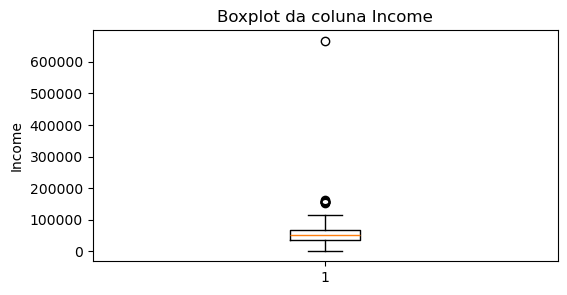

In [12]:
plt.figure(figsize=(6, 3))
plt.boxplot(base['Income'])

plt.title('Boxplot da coluna Income')
plt.ylabel('Income')

plt.show()

Analisando os valores e o gráfico, observa-se a presença de duas regiões distintas de outliers: uma próxima de `200.000` e outra em `666.666`.

Os outliers da primeira região foram mantidos, pois uma renda anual de aproximadamente `200.000` corresponde a cerca de `16.500` mensais, um valor elevado, mas ainda plausível dentro do contexto da análise.

Por outro lado, o valor de `666.666` representa uma renda extremamente fora do padrão observado no conjunto de dados, podendo indicar um erro de registro ou um caso muito discrepante. Portanto, esse registro será removido do dataframe.

In [13]:
base = base.drop(base[base['Income'] == 666666].index)

### Coluna `Kidhome`

Esta coluna não apresenta uma distribuição balanceada, já que sua média está distante da mediana. No entanto, isso não representa um problema, pois não há presença de outliers. Portanto, não é necessário realizar nenhum tratamento nesta coluna.

### Coluna `Recency`

Esta coluna está balanceada, apresentando uma média igual a mediana e não há outliers

### Colunas `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts` e `MntGoldProds`

As colunas relacionadas aos valores gastos com produtos apresentam alta variabilidade, o que resulta em distribuições desbalanceadas. Isso ocorre porque os clientes possuem hábitos de consumo diferentes, e remover os outliers significaria excluir padrões reais de comportamento das análises.

Além disso, os valores considerados outliers não aparentam ser absurdos ou inconsistentes a ponto de indicar possíveis erros de digitação ou de coleta de dados. Portanto, essas colunas serão mantidas sem alterações.

### Coluna `NumStorePurchases` e `NumWebVisitsMonth`

Estas colunas estão balanceadas, apresentando uma média igual a mediana e não possuem outliers

### Coluna `Complain`

Coluna desbalanceada. Uma coluna binária com média igual a 0.0094 indica que a maioria dos valores são 0. Não há outliers.

### Coluna `WebPurchases` (Variável target)

Coluna balanceada. Uma coluna binária com média igual a 0.5 indica que a metade dos valores são 0 e a outra metade são 1. Não há outliers

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








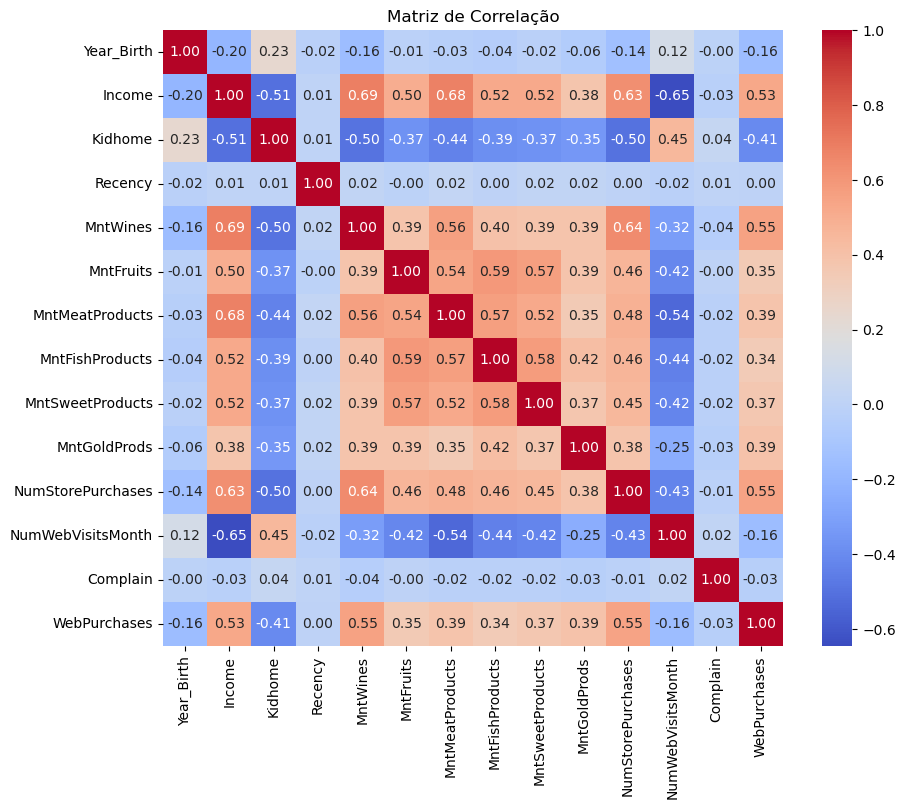

In [14]:
# Matriz de correlação
correlation_matrix = base.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

A partir da matriz de correlação, observa-se que há duas variáveis pouco relevantes para o modelo.

A variável `Recency` apresenta correlação  nula com a variável target, indicando ausência de relação linear entre elas.

Já a variável `Complain` possui correlação de aproximadamente `-0.03`, um valor muito próximo de 0, o que também sugere baixa relevância para o modelo. Portanto, ambas podem ser removidas do dataframe.

In [15]:
base = base.drop(columns=['Recency', 'Complain'])

### Separação em X e y

In [16]:
X = base.drop(columns='WebPurchases')
y = base['WebPurchases']

### Separação em treino e teste

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=37)

### Transformação de variáveis categóricas e padronização

In [18]:
# prepara o ColumnsTransformer
transformador = ColumnTransformer([
    ('edu', OrdinalEncoder(categories=[['Basic','2n Cycle','Graduation','Master','PhD']]), ['Education']),
    ('cat', OneHotEncoder(), ['Marital_Status']),
    ('num', StandardScaler(), X.drop(columns=['Education', 'Marital_Status']).columns.tolist())
])

# Aprende nos dados de treino
X_train_pros = transformador.fit_transform(X_train)

# Aplica nos dados de teste
X_test_pros = transformador.transform(X_test)

Como o `OneHotEncoder` cria diversas colunas adicionais, será aplicada a técnica de PCA para reduzir a dimensionalidade do dataframe.

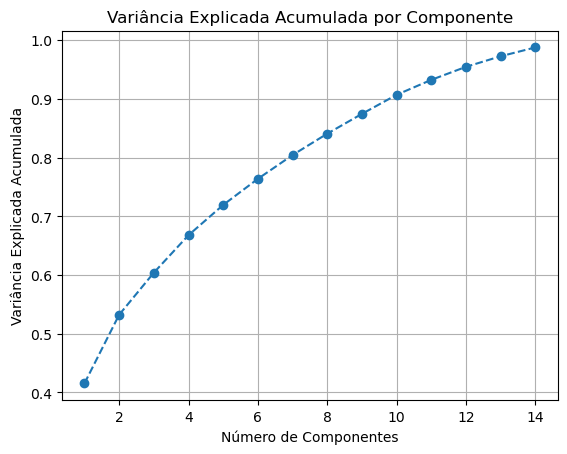

In [19]:
# Cria o PCA para que ele explique 98% da variância
pca = PCA(n_components=0.98)

# Ajustando o PCA aos dados de treino
X_train_pca = pca.fit_transform(X_train_pros)

# Transforma o teste
X_test_pca = pca.transform(X_test_pros)

# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

# Plotando a variância explicada acumulada
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

## Foram escolhidos 2 modelos: Random Forest e Regressão Logística

### 1) Regressão Logística

In [20]:
# Etapa de treinamento
logistic_reg = LogisticRegression(random_state = 37)

# Treina o modelo
logistic_reg.fit(X_train_pca, y_train)

print(f'Coeficinente angular da reta: {logistic_reg.coef_}')
print(f'Coeficinente linear da reta: {logistic_reg.intercept_}')

Coeficinente angular da reta: [[ 0.73479523  0.31252961 -0.61067893  0.93762136  0.23038672 -0.54235324
   0.09283961  0.14061511 -0.08765841 -0.33507672  0.043409   -0.03737742
  -0.14972039  1.20079824]]
Coeficinente linear da reta: [0.18898837]


In [21]:
Y_pred_reg = logistic_reg.predict(X_test_pca)
Y_pred_reg

array([1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,

### 2) Random Forest

In [22]:
# Iniciando o modelo Random Forest
rf_model = RandomForestClassifier(random_state=37)

# Treinando o modelo
rf_model.fit(X_train_pca, y_train)

# Fazendo previsões no conjunto de teste
Y_pred_rf = rf_model.predict(X_test_pca)
Y_pred_rf

array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,

# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

### Avaliando a Regressão Logística

In [23]:
accuracy_reg = accuracy_score(y_test, Y_pred_reg)
report_reg = classification_report(y_test, Y_pred_reg)
conf_matrix_reg = confusion_matrix(y_test, Y_pred_reg)

print(f"Acurácia: {accuracy_reg:.2f}")
print("Relatório de Classificação:\n", report_reg)
print("Matriz de Confusão:\n", conf_matrix_reg)

Acurácia: 0.87
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88       243
           1       0.85      0.86      0.86       204

    accuracy                           0.87       447
   macro avg       0.87      0.87      0.87       447
weighted avg       0.87      0.87      0.87       447

Matriz de Confusão:
 [[212  31]
 [ 28 176]]


AUC: 0.87


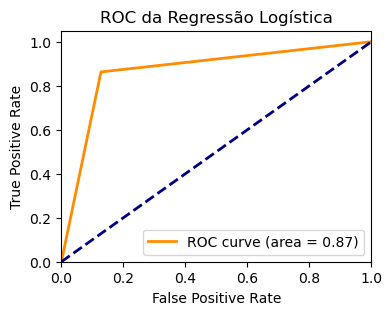

In [24]:
fpr_reg, tpr_reg, thresholds_reg = roc_curve(y_test, Y_pred_reg)

# Calcular a AUC
roc_auc_reg = roc_auc_score(y_test, Y_pred_reg)
print("AUC: {:.2f}".format(roc_auc_reg))


plt.figure(figsize=(4, 3))
plt.plot(fpr_reg, tpr_reg, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_reg)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC da Regressão Logística')
plt.legend(loc="lower right")
plt.show()

### Avaliando a Random Forest

In [25]:
accuracy_rf = accuracy_score(y_test, Y_pred_rf)
report_rf = classification_report(y_test, Y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, Y_pred_rf)

print(f"Acurácia: {accuracy_rf:.2f}")
print("Relatório de Classificação:\n", report_rf)
print("Matriz de Confusão:\n", conf_matrix_rf)

Acurácia: 0.89
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.94      0.84      0.89       243
           1       0.83      0.94      0.88       204

    accuracy                           0.89       447
   macro avg       0.89      0.89      0.89       447
weighted avg       0.89      0.89      0.89       447

Matriz de Confusão:
 [[204  39]
 [ 12 192]]


AUC: 0.89


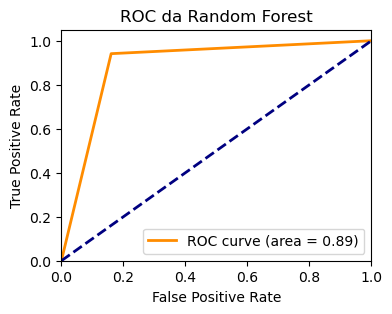

In [26]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, Y_pred_rf)

# Calcular a AUC
roc_auc_rf = roc_auc_score(y_test, Y_pred_rf)
print("AUC: {:.2f}".format(roc_auc_rf))


plt.figure(figsize=(4, 3))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC da Random Forest')
plt.legend(loc="lower right")
plt.show()

## O modelo Random Forest apresentou melhor desempenho

Ambos os modelos apresentaram resultados bastante semelhantes nas previsões da classe negativa. A Regressão Logística obteve 212 `Verdadeiros Negativos` e 31 `Falsos Positivos`, enquanto a Random Forest apresentou 204 `Verdadeiros Negativos` e 39 `Falsos Positivos`. A principal diferença entre os modelos está nas previsões da classe positiva.

O modelo de Regressão Logística obteve:

* 28 `Falsos Negativos`
* 176 `Verdadeiros Positivos`

Já o modelo Random Forest apresentou:

* 12 `Falsos Negativos`
* 192 `Verdadeiros Positivos`

Esses resultados se refletem diretamente nas métricas de desempenho.

### Regressão Logística

* Acurácia = 0.87
* Precisão = 0.87
* Recall = 0.87
* F1-score = 0.87

### Random Forest

* Acurácia = 0.89
* Precisão = 0.89
* Recall = 0.89
* F1-score = 0.89

Portanto, observa-se que ambos os modelos apresentaram resultados muito próximos e bastante satisfatórios. Ainda assim, a Random Forest demonstrou desempenho ligeiramente superior, principalmente por reduzir a quantidade de falsos negativos e aumentar o número de verdadeiros positivos. Além disso, os bons resultados obtidos indicam que a etapa de pré-processamento dos dados foi realizada de forma eficiente, contribuindo para a boa capacidade preditiva dos modelos.